## Introduction to time series plots

earthkit-plots supports time series plotting through the `TimeSeries`
class and the high-level `ekp.timeseries` namespace.  This notebook
introduces both approaches using ERA5 hourly 2-metre temperature at a
single location retrieved from the Copernicus Climate Data Store (CDS).

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

### Fetching the data

We request a short ERA5 time series for Reading, UK (51.5°N, 1°W) over a
few days.  The CDS `reanalysis-era5-single-levels-timeseries` dataset
returns hourly values at a single point, which we convert to an xarray
Dataset.

In [2]:
dataset = "reanalysis-era5-single-levels-timeseries"
request = {
    "variable": ["2m_temperature"],
    "location": {"longitude": -1, "latitude": 51.5},
    "date": ["2025-08-20/2025-08-23"],
    "data_format": "netcdf",
}

data = ekd.from_source("cds", dataset, request)
ds = data.to_xarray()
ds

<xarray.Dataset> Size: 1kB
Dimensions:     (valid_time: 96)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 768B 2025-08-20 ... 2025-08-23T23...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    t2m         (valid_time) float32 384B dask.array<chunksize=(96,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

### High-level API: `ekp.timeseries`

The simplest entry point is `ekp.timeseries`, which creates a complete
time series plot in a single call.  Pass the xarray Dataset and any
keyword arguments you want — units conversion, tick formatting and title
template strings are all handled automatically.

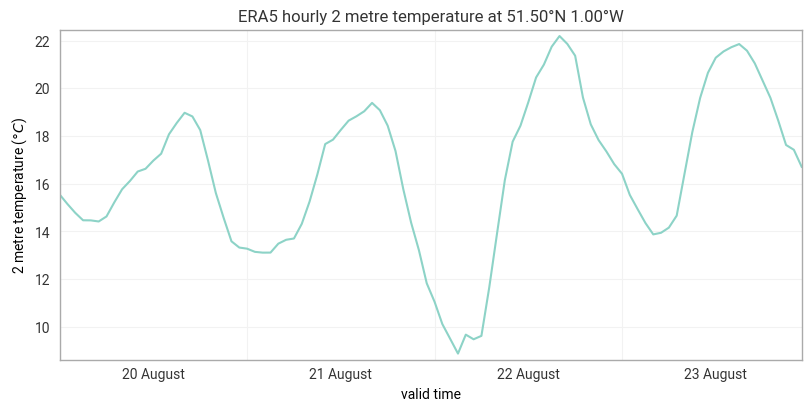

In [3]:
ekp.timeseries.line(
    ds,
    units="celsius",
    title="ERA5 hourly {variable_name} at {latitude:%Lt} {longitude:%Ln}",
    xticks={"frequency": "D", "format": "%d %B", "period": True},
).show()

You can swap axes by passing an explicit x or y argument. The units conversion will still work!

But be careful - make sure that you swap any tick formatting from x to y.

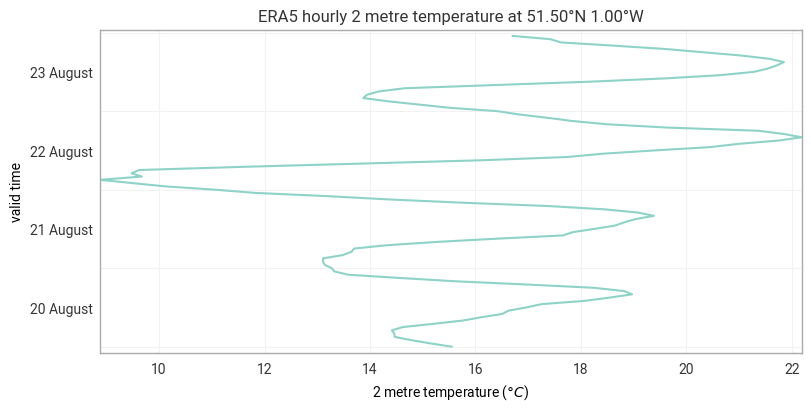

In [4]:
ekp.timeseries.line(
    ds,
    x="t2m",
    x_units="celsius",
    title="ERA5 hourly {variable_name} at {latitude:%Lt} {longitude:%Ln}",
    yticks={"frequency": "D", "format": "%d %B", "period": True},
).show()

### Lower-level API: `TimeSeries.line`

For more control — or to overlay multiple lines on the same axes — use
`Subplot.line` directly.  Here we create a `Subplot`, add the time
series as a line, set axis labels manually, and call `show`.

In [ ]:
(
    ekp.TimeSeries()
    .line(ds, units="fahrenheit", color="steelblue", linewidth=2)
    .xticks(
        frequency="D",
        format="%d %B",
        period=True,
    )
    .ylabel("{variable_name} ({units})")
    .title("ERA5 hourly {variable_name} in {location:%c}, {location:%C}")
    .show()
)

### What's next?

The next notebook shows how to create climate stripe plots — a powerful
way to visualise long-term temperature anomalies at a glance.